# Quickstart: ECMWF AIFS Single forecast - dynamical.org Icechunk Zarr

ECMWF's Artificial Intelligence Forecasting System (AIFS) is an AI based weather model that produces global forecasts. It generates 15-day forecasts at 0.25 degree resolution every 6 hours.

This dataset provides AIFS Single forecasts from April 2024 to present, transformed into a single analysis-ready dataset by [dynamical.org](https://dynamical.org).

Dataset documentation: https://dynamical.org/catalog/ecmwf-aifs-single-forecast/

Dataset licenced [CC-BY-4.0](https://creativecommons.org/licenses/by/4.0/) and [ECMWF Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog

In [2]:
import dynamical_catalog

ds = dynamical_catalog.open("ecmwf-aifs-single-forecast", chunks=None)
ds

<xarray.Dataset> Size: 13TB
Dimensions:                                     (init_time: 3011,
                                                 lead_time: 61, latitude: 721,
                                                 longitude: 1440)
Coordinates:
  * init_time                                   (init_time) datetime64[ns] 24kB ...
    expected_forecast_length                    (init_time) timedelta64[ns] 24kB ...
    ingested_forecast_length                    (init_time) timedelta64[ns] 24kB ...
  * lead_time                                   (lead_time) timedelta64[ns] 488B ...
    valid_time                                  (init_time, lead_time) datetime64[ns] 1MB ...
  * latitude                                    (latitude) float64 6kB 90.0 ....
  * longitude                                   (longitude) float64 12kB -180...
    spatial_ref                                 int64 8B ...
Data variables: (12/17)
    downward_short_wave_radiation_flux_surface  (init_time, lead_time, latitude, longitude) float32 763GB ...
    dew_point_temperature_2m                    (init_time, lead_time, latitude, longitude) float32 763GB ...
    geopotential_height_500hpa                  (init_time, lead_time, latitude, longitude) float32 763GB ...
    geopotential_height_925hpa                  (init_time, lead_time, latitude, longitude) float32 763GB ...
    downward_long_wave_radiation_flux_surface   (init_time, lead_time, latitude, longitude) float32 763GB ...
    precipitation_surface                       (init_time, lead_time, latitude, longitude) float32 763GB ...
    ...                                          ...
    temperature_850hpa                          (init_time, lead_time, latitude, longitude) float32 763GB ...
    temperature_925hpa                          (init_time, lead_time, latitude, longitude) float32 763GB ...
    wind_u_100m                                 (init_time, lead_time, latitude, longitude) float32 763GB ...
    wind_v_100m                                 (init_time, lead_time, latitude, longitude) float32 763GB ...
    wind_v_10m                                  (init_time, lead_time, latitude, longitude) float32 763GB ...
    wind_u_10m                                  (init_time, lead_time, latitude, longitude) float32 763GB ...
Attributes:
    dataset_id:           ecmwf-aifs-single-forecast
    dataset_version:      0.1.0
    name:                 ECMWF AIFS Single forecast
    description:          Weather forecasts from the ECMWF Artificial Intelli...
    attribution:          ECMWF AIFS Single forecast data processed by dynami...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2024-04-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-360 hours (0-15 days) ahead
    forecast_resolution:  6 hourly

This is a forecast dataset with two time dimensions: `init_time` (when the forecast run began) and `lead_time` (how far ahead the forecast extends). The `valid_time` coordinate combines these to give the actual forecasted time.

It also has `latitude` and `longitude` spatial dimensions. Lets begin by extracting a forecast time series at a point, and then create a map at a single point in time.

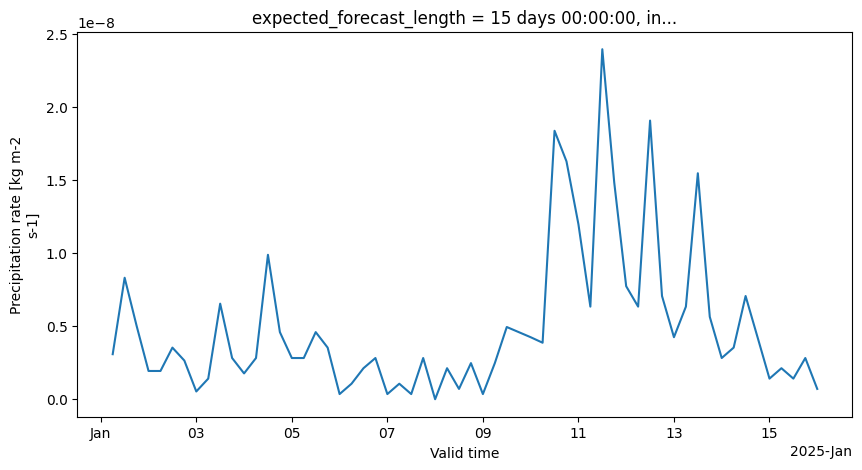

In [3]:
# 15-day precipitation forecast for Nairobi, Kenya
# Select a specific forecast run (init_time) and location and plot the full forecast time series
plot_ds = ds.sel(init_time="2025-01-01T00", latitude=-1.3, longitude=36.8, method="nearest")
_ = plot_ds["precipitation_surface"].plot(x="valid_time", figsize=(10, 5))

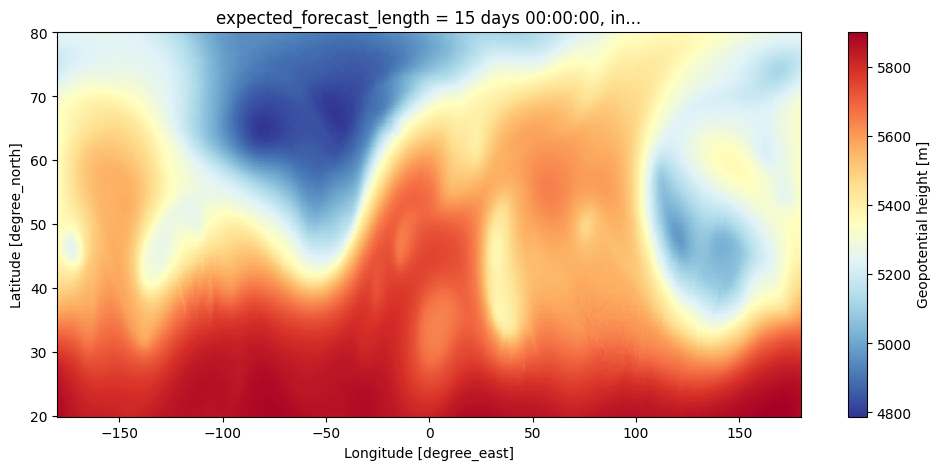

In [4]:
# Geopotential height, a measure of air pressure, 5 days ahead
# Reveals the large scale ridges and troughs in the atmosphere that steer weather systems
#
# Select a single time step of a forecast run to create a map
(
    ds["geopotential_height_500hpa"]
    .sel(init_time="2025-02-01T00", lead_time="5d")
    .sel(latitude=slice(80, 20))
    .plot(figsize=(12, 5), cmap="RdYlBu_r")
)

### How strong was the wind during Storm Éowyn?

Storm Éowyn struck Ireland and the UK on January 24, 2025 with record-breaking winds. We can compute 10m wind speed from the u and v components and map the storm's intensity.

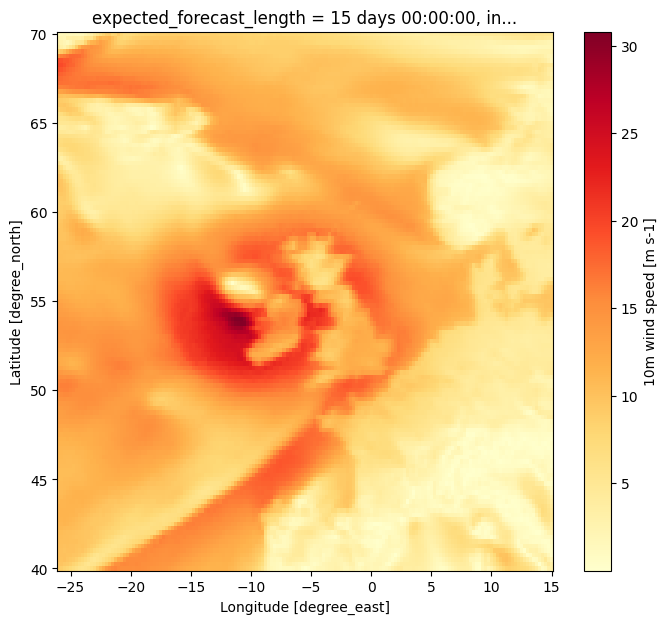

In [5]:
import numpy as np

# 10m wind speed over the British Isles, AIFS forecast initialized Jan 24 00Z, 6 hours ahead
plot_ds = ds.sel(
    init_time="2025-01-24T00",
    lead_time="6h",
    latitude=slice(70, 40),
    longitude=slice(-26, 15),
)

wind_speed = np.sqrt(plot_ds["wind_u_10m"]**2 + plot_ds["wind_v_10m"]**2)
wind_speed.attrs["units"] = "m s-1"
wind_speed.attrs["long_name"] = "10m wind speed"
wind_speed.plot(figsize=(8, 7), cmap="YlOrRd")

### Where is the coldest temperature forecast in the Northern Hemisphere right now?

Using the most recent forecast initialization, we can find the location with the lowest predicted 2m temperature over the next 24 hours.

Text(0.5, 1.0, 'Coldest 24h forecast: -30.1 °C at (68.5°, -122.5°)\nForecast initialized: 2026-04-23 12:00:00')

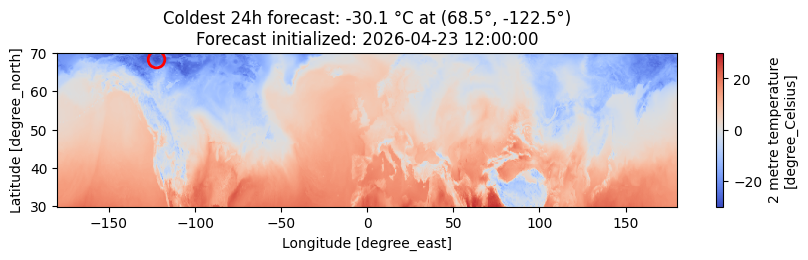

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

latest_init = ds.init_time[-1].values

cold_forecast = (
    ds["temperature_2m"]
    .sel(init_time=latest_init, lead_time=slice("0h", "23h"))
    .sel(latitude=slice(70, 30))  # Northern Hemisphere mid-latitudes
    .min(dim="lead_time")
    .load()
)

min_val = float(cold_forecast.min())
min_loc = cold_forecast.argmin(dim=["latitude", "longitude"])
min_lat = float(cold_forecast.latitude[min_loc["latitude"]])
min_lon = float(cold_forecast.longitude[min_loc["longitude"]])

fig, ax = plt.subplots(figsize=(10, 2))
cold_forecast.plot(ax=ax, cmap="coolwarm")
# Draw a red circle around the coldest point
ax.plot(min_lon, min_lat, "ro", markersize=12, markerfacecolor="none", markeredgewidth=2)
ax.set_title(f"Coldest 24h forecast: {min_val:.1f} °C at ({min_lat:.1f}°, {min_lon:.1f}°)\nForecast initialized: {pd.Timestamp(latest_init)}")

### Animated map

Longwave radiation varies with cloud cover and atmospheric moisture, revealing weather systems as they evolve. Let's create an animated map.

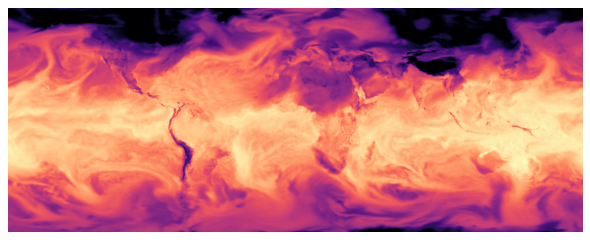

In [7]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

# Animation of downward longwave radiation over a week-long forecast
data = (
    ds["downward_long_wave_radiation_flux_surface"]
    .sel(
        init_time="2026-03-01T00",
        lead_time=slice("6h", "7d"),
        latitude=slice(70, -70),
    )
    .load()
)


scale = 0.4
dpi = 80
fig, ax = plt.subplots(figsize=(data.longitude.size * scale / dpi, data.latitude.size * scale / dpi), dpi=dpi)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.axis("off")

img = ax.imshow(data.isel(lead_time=0), cmap="magma", vmin=150, vmax=450)
anim = FuncAnimation(fig=fig, frames=data, func=lambda frame: img.set_data(frame), interval=200)

HTML(anim.to_jshtml())

### Community challenge

AIFS is one of a new generation of AI based weather models. With global forecasts out to 15 days, there are many avenues to explore.

Here are a few for inspiration:
- How quickly do AIFS forecasts converge on a notable weather event? Pick an event and plot the same location and variable across successive initializations — from the 15-day-ahead forecast through the 6-hour-ahead. How many days out does AIFS "lock on"?
- Track a tropical cyclone by extracting minimum sea level pressure or maximum wind speed in a bounding box at each lead time (e.g. Typhoon Yagi, September 2024). How does the predicted storm track shift across initializations?
- Combine 2m temperature and dew point to compute wet-bulb temperature across South Asia during a summer heat wave. Map where forecast conditions exceed dangerous thresholds, and explore how far ahead AIFS can reliably predict those events.